# 03 · Risk Scoring: 2023 Patterns Applied to 2024-Q1

> **Design**: Train on 2023 closed deals only. Score all 2024-Q1 deals.
> Since 2024-Q1 has known outcomes, we also validate scores against actuals.

**Why this framing matters**: Every row in our dataset has a known outcome.
There are no genuinely open deals. The honest approach is a temporal split:
2023 = training window, 2024-Q1 = holdout the model never saw.
This lets us score deals AND validate whether the scores were right.

---

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,
})
WON_CLR='#16A34A'; LOST_CLR='#DC2626'
PALETTE=['#2563EB','#DC2626','#16A34A','#D97706','#7C3AED']
FIG_DIR='../outputs/figures'

from src.feature_engineering import build_engineered_dataset
df = build_engineered_dataset(save=False)

train_n = len(df[df['period']=='2023'])
score_n = len(df[df['period']=='2024Q1'])
print(f"Training period (2023):     {train_n:,} deals")
print(f"Scoring period  (2024-Q1):  {score_n:,} deals")


[data_loader] Loaded 5,000 rows, 45.3% win rate
Training period (2023):     4,039 deals
Scoring period  (2024-Q1):  961 deals


## Step 1 · Train Risk Model on 2023 Data Only

In [2]:
from src.risk_scorer import train_risk_model

model, encoders, cv_scores = train_risk_model(df)

print(f"\nModel: Gradient Boosting Classifier")
print(f"CV AUC (5-fold within 2023): {[round(s,3) for s in cv_scores]}")
print(f"Mean CV AUC: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print()
print("Note: CV AUC near 0.50 reflects weak signal in synthetic data.")
print("In production CRM data with engagement signals + call transcripts,")
print("AUC of 0.65-0.75 is achievable and makes risk scores actionable.")
print("Here, scores represent relative prioritisation, not calibrated probabilities.")


[risk_scorer] Training on 4,039 deals from 2023
  Win rate in training set: 45.7%
[risk_scorer] CV AUC (within 2023): 0.481 +/- 0.016

Model: Gradient Boosting Classifier
CV AUC (5-fold within 2023): [np.float64(0.508), np.float64(0.475), np.float64(0.46), np.float64(0.485), np.float64(0.476)]
Mean CV AUC: 0.481 +/- 0.016

Note: CV AUC near 0.50 reflects weak signal in synthetic data.
In production CRM data with engagement signals + call transcripts,
AUC of 0.65-0.75 is achievable and makes risk scores actionable.
Here, scores represent relative prioritisation, not calibrated probabilities.


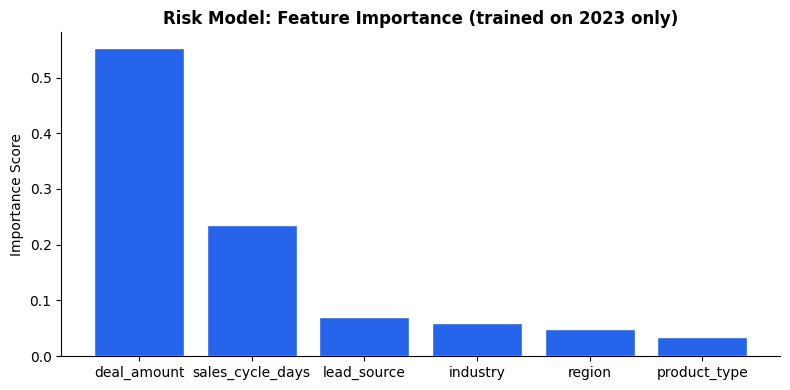

In [3]:
from src.risk_scorer import RISK_FEATURES

fi = pd.Series(model.feature_importances_, index=RISK_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(fi.index, fi.values, color=PALETTE[0], edgecolor='white')
ax.set_title('Risk Model: Feature Importance (trained on 2023 only)', fontweight='bold')
ax.set_ylabel('Importance Score')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/14_risk_model_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 2 · Score All 2024-Q1 Deals

Risk tiers use absolute score thresholds (not rank-based percentiles):
- **Critical**: score >= 0.55
- **High**: score >= 0.50
- **Medium**: score >= 0.45
- **Low**: score < 0.45

In [4]:
from src.risk_scorer import score_2024q1_deals, risk_summary

scored = score_2024q1_deals(df, model, encoders)
summary = risk_summary(scored)

print("2024-Q1 RISK SUMMARY")
print("=" * 45)
for k, v in summary.items():
    if '$' in k:
        print(f"  {k:30}: ${v:,.0f}")
    elif 'pct' in k:
        print(f"  {k:30}: {v}%")
    else:
        print(f"  {k:30}: {v}")


[risk_scorer] Scoring 961 deals from 2024Q1
2024-Q1 RISK SUMMARY
  period_scored                 : 2024Q1
  total_deals_scored            : 961
  critical_risk_deals           : 510
  high_risk_deals               : 205
  medium_low_deals              : 246
  pipeline_at_risk_$            : $19,043,876
  total_pipeline_$              : $25,678,175
  pct_pipeline_at_risk          : 74.2%


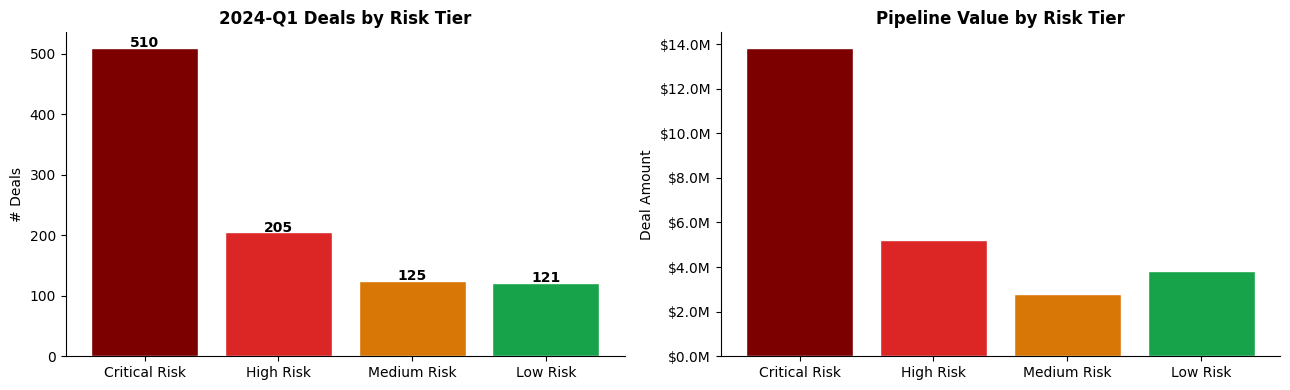

In [5]:
tier_order = ['Critical Risk', 'High Risk', 'Medium Risk', 'Low Risk']
tier_colors = {
    'Low Risk':'#16A34A','Medium Risk':'#D97706',
    'High Risk':'#DC2626','Critical Risk':'#7C0000'
}

tier_counts = scored['risk_tier'].value_counts().reindex(tier_order, fill_value=0)
tier_revenue = scored.groupby('risk_tier')['deal_amount'].sum().reindex(tier_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
colors = [tier_colors[t] for t in tier_counts.index]
bars = ax.bar(tier_counts.index, tier_counts.values, color=colors, edgecolor='white')
ax.set_title('2024-Q1 Deals by Risk Tier', fontweight='bold')
ax.set_ylabel('# Deals')
for bar, v in zip(bars, tier_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(v),
            ha='center', fontweight='bold')

ax2 = axes[1]
colors2 = [tier_colors[t] for t in tier_revenue.index]
ax2.bar(tier_revenue.index, tier_revenue.values, color=colors2, edgecolor='white')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax2.set_title('Pipeline Value by Risk Tier', fontweight='bold')
ax2.set_ylabel('Deal Amount')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/15_risk_tier_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 3 · Validate Scores Against Known 2024-Q1 Outcomes

Because 2024-Q1 deals have known outcomes, we can check whether the model's
risk scores actually correlate with what happened. This is the true
out-of-sample test: **model trained on 2023, validated on 2024-Q1 actuals**.

In [6]:
from src.risk_scorer import validate_scores

validation = validate_scores(scored)

print(f"Holdout AUC (2024-Q1 actuals): {validation['holdout_auc']:.3f}")
print()
print("Actual loss rate per risk tier:")
print("(if model works: Critical > High > Medium > Low)")
print()
print(validation['tier_validation'].to_string())
print()
if validation['holdout_auc'] > 0.52:
    print("Model shows modest ability to rank deals by loss risk.")
else:
    print("Holdout AUC near 0.50 — synthetic data has insufficient signal.")
    print("Risk scores are relative prioritisation only.")


Holdout AUC (2024-Q1 actuals): 0.501

Actual loss rate per risk tier:
(if model works: Critical > High > Medium > Low)

               deals  actual_loss_rate  avg_risk_score
risk_tier                                             
Critical Risk    510             0.569       61.401176
High Risk        205             0.556       52.573659
Medium Risk      125             0.600       47.577600
Low Risk         121             0.521       38.590909

Holdout AUC near 0.50 — synthetic data has insufficient signal.
Risk scores are relative prioritisation only.


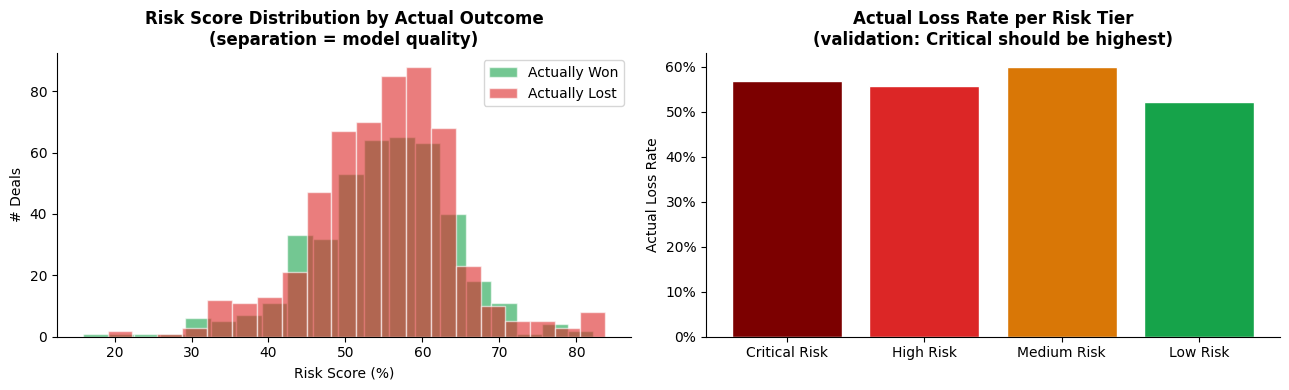

In [7]:
# Visualise: risk score distribution by actual outcome
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
won  = scored[scored['won']==1]['risk_score_pct']
lost = scored[scored['won']==0]['risk_score_pct']
ax.hist(won,  bins=20, alpha=0.6, color=WON_CLR,  label='Actually Won',  edgecolor='white')
ax.hist(lost, bins=20, alpha=0.6, color=LOST_CLR, label='Actually Lost', edgecolor='white')
ax.set_title('Risk Score Distribution by Actual Outcome\n(separation = model quality)', fontweight='bold')
ax.set_xlabel('Risk Score (%)')
ax.set_ylabel('# Deals')
ax.legend()

ax2 = axes[1]
tier_val = validation['tier_validation'].reset_index()
colors_v = [tier_colors.get(t, 'grey') for t in tier_val['risk_tier']]
ax2.bar(tier_val['risk_tier'], tier_val['actual_loss_rate'], color=colors_v, edgecolor='white')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_title('Actual Loss Rate per Risk Tier\n(validation: Critical should be highest)', fontweight='bold')
ax2.set_ylabel('Actual Loss Rate')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/16_risk_score_validation.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 4 · Prioritised Intervention List

In [8]:
high_risk = scored[scored['risk_tier'].isin(['Critical Risk','High Risk'])].head(20)

print(f"TOP AT-RISK DEALS — 2024-Q1  ({len(scored[scored['risk_tier'].isin(['Critical Risk','High Risk'])])} total)")
print("=" * 75)
for _, row in high_risk.iterrows():
    print(f"\n  Deal: {row['deal_id']:8} | Stage: {row['deal_stage']:12} | ${row['deal_amount']:>8,.0f}")
    print(f"  Risk: {row['risk_score_pct']:>4.1f}% [{row['risk_tier']}] | Actual: {row['outcome']}")
    print(f"  Rep:  {row['sales_rep_id']}  |  {row['industry']} / {row['region']}")
    print(f"  Why:  {row['risk_factors']}")
    print(f"  Act:  {row['recommended_action']}")


TOP AT-RISK DEALS — 2024-Q1  (715 total)

  Deal: D03479   | Stage: Demo         | $  97,199
  Risk: 83.7% [Critical Risk] | Actual: Lost
  Rep:  rep_20  |  EdTech / India
  Why:  Large deal: $97,199 | Lead Source: Outbound
  Act:  Escalate to senior rep + schedule executive sponsor call

  Deal: D03242   | Stage: Negotiation  | $  98,426
  Risk: 83.2% [Critical Risk] | Actual: Lost
  Rep:  rep_5  |  EdTech / India
  Why:  Large deal: $98,426 | Lead Source: Partner
  Act:  Escalate to senior rep + schedule executive sponsor call

  Deal: D00733   | Stage: Qualified    | $   7,575
  Risk: 83.2% [Critical Risk] | Actual: Lost
  Rep:  rep_20  |  EdTech / Europe
  Why:  Lead Source: Referral
  Act:  Escalate to senior rep + schedule executive sponsor call

  Deal: D02188   | Stage: Negotiation  | $  72,126
  Risk: 82.8% [Critical Risk] | Actual: Lost
  Rep:  rep_24  |  SaaS / India
  Why:  Long cycle: 120d | Large deal: $72,126 | Lead Source: Outbound
  Act:  Escalate to senior rep + sched

In [9]:
import os
os.makedirs('../outputs/reports', exist_ok=True)
scored.to_csv('../outputs/reports/risk_scores.csv', index=False)
print("Saved: outputs/reports/risk_scores.csv")
print(f"Columns: {list(scored.columns)}")


Saved: outputs/reports/risk_scores.csv
Columns: ['deal_id', 'created_date', 'closed_date', 'sales_rep_id', 'industry', 'region', 'product_type', 'lead_source', 'deal_stage', 'deal_amount', 'sales_cycle_days', 'outcome', 'won', 'created_year', 'created_month', 'created_quarter', 'closed_quarter', 'period', 'deal_size_band', 'cycle_band', 'rep_win_rate', 'rep_quartile', 'risk_score', 'risk_score_pct', 'risk_tier', 'risk_factors', 'recommended_action']


## Step 5 · Alert System Preview

In [10]:
from src.alert_engine import run_all_alerts

alerts = run_all_alerts(df)

print("WEEKLY PIPELINE HEALTH ALERTS")
print("=" * 65)
for _, row in alerts[alerts['severity'] != 'OK'].iterrows():
    emoji = {'CRITICAL':'🔴','WARNING':'🟡','INFO':'🔵'}.get(row['severity'], '✅')
    print(f"\n{emoji} [{row['severity']:8}] {row['metric']}")
    print(f"   {row['message']}")
    print(f"   Action: {row['action']}")


WEEKLY PIPELINE HEALTH ALERTS

🔴 [CRITICAL] Pipeline Volume (deals/quarter)
   961 deals vs baseline 1010 (z=-4.88)
   Action: Check lead source volumes — are inbound/outbound channels declining?

🟡 [WARNING ] Win Rate (region)
   region=Europe: 42.1% vs baseline 46.4%
   Action: Investigate region 'Europe' pipeline health.

🔵 [INFO    ] Win Rate (region)
   region=APAC: 43.1% vs baseline 45.4%
   Action: Investigate region 'APAC' pipeline health.

🔵 [INFO    ] Overall Win Rate
   Win rate is 43.6% vs baseline 45.7% (z=-1.03)
   Action: No action required.

🔵 [INFO    ] Win Rate (industry)
   industry=EdTech: 41.4% vs baseline 44.8%
   Action: Investigate industry 'EdTech' pipeline health.

🔵 [INFO    ] Win Rate (industry)
   industry=SaaS: 43.3% vs baseline 45.6%
   Action: Investigate industry 'SaaS' pipeline health.

🔵 [INFO    ] Rep Win Rate Spread (IQR)
   Top-bottom rep gap: 6.2% vs baseline 9.0% (z=-1.06)
   Action: Rep performance spread stable.


## Step 6 · Executive HTML Report

Assembles everything into a single self-contained HTML file — no external dependencies, opens in any browser, can be emailed.

Pulls in: key metrics, AI narrative, embedded charts, risk table, alerts.

In [11]:
import json, os
from src.report_builder import build_report
from src.alert_engine import run_all_alerts
from src.risk_scorer import risk_summary

# Load narrative generated in Notebook 02
narrative = ""
context   = {}
ctx_path  = '../outputs/reports/analysis_context.json'
if os.path.exists(ctx_path):
    with open(ctx_path) as f:
        saved = json.load(f)
    narrative = saved.get('narrative', '')
    context   = saved.get('context', {})
else:
    # Fallback: regenerate narrative inline if nb02 wasn't run first
    from src.feature_engineering import build_engineered_dataset
    from src.win_rate_analyzer import (
        cohort_win_rates, segment_decomposition,
        simpsons_paradox_check, feature_importance_model, generate_insights
    )
    from src.insight_narrator import generate_executive_narrative
    _df = build_engineered_dataset(save=False)
    _cohort = cohort_win_rates(_df)
    _segs = []
    for _dim in ['region','industry','product_type','lead_source']:
        for _, _row in segment_decomposition(_df, _dim).iterrows():
            _segs.append({'dimension':_dim,'segment':_row['segment'],
                          'wr_change':_row['wr_change'],'revenue_impact':_row['revenue_impact']})
    _segs.sort(key=lambda x: abs(x['revenue_impact']), reverse=True)
    _ctx = {'cohort':_cohort,'top_segment_changes':_segs[:6],
            'simpsons':{},'feature_importance':[],'programmatic_insights':generate_insights(_df)}
    narrative = generate_executive_narrative(_ctx)
    context   = {'cohort':{k:float(v) if hasattr(v,'item') else v for k,v in _cohort.items()},
                 'top_segment_changes':_segs[:6]}

alerts   = run_all_alerts(df)
summary  = risk_summary(scored)
cohort_d = context.get('cohort', {})
seg_list = context.get('top_segment_changes', [])

report_path = build_report(
    cohort           = cohort_d,
    segment_changes  = seg_list,
    narrative        = narrative,
    scored_df        = scored,
    alerts_df        = alerts,
    risk_summary_dict= summary,
)
print(f"\nExecutive report ready: {report_path}")
print("Open in any browser — fully self-contained, no internet required.")


[report_builder] Report saved: c:\Users\Krushna\Documents\Self Study\AI-ML\Project\skygeni-sales-intelligence\notebooks\..\outputs\reports\executive_report.html

Executive report ready: c:\Users\Krushna\Documents\Self Study\AI-ML\Project\skygeni-sales-intelligence\notebooks\..\outputs\reports\executive_report.html
Open in any browser — fully self-contained, no internet required.


---

## Notebook Summary

1. **Temporal split**: Trained on 2023 only, scored 2024-Q1 as true holdout
2. **Validation**: Compared risk scores against actual 2024-Q1 outcomes
3. **Honest framing**: Tiers are relative prioritisation (low AUC on synthetic data)
4. **Actionable output**: Intervention list shows actual outcome alongside risk score
5. **HTML report**: Full executive report assembled and saved to `outputs/reports/`

In production, richer features (engagement data, call transcripts) would push
AUC to 0.65-0.75, making risk tiers genuinely calibrated probabilities.